In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

C:\Users\fabio\AppData\Local\Temp\ipykernel_16324\164360330.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_transformed = df.applymap(transform)
C:\Users\fabio\AppData\Local\Temp\ipykernel_16324\164360330.py:15: RuntimeWarning: invalid value encountered in log1p
  return np.log1p((base - 1) * x) / np.log(base)


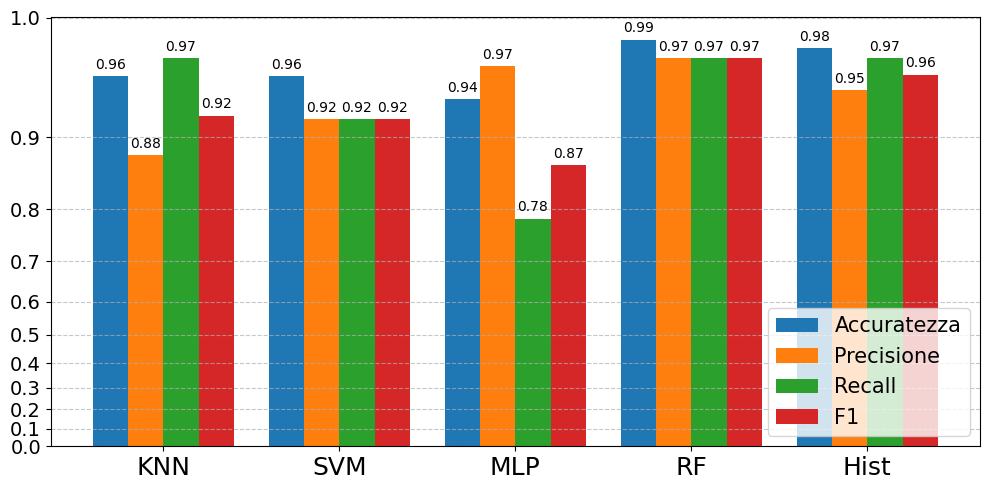

In [2]:
modelli = ['KNN', 'SVM', 'MLP', 'RF', 'Hist']
accuratezza = [0.959, 0.959, 0.939, 0.986, 0.980]
precisione = [0.878, 0.919, 0.967, 0.973, 0.947]
recall = [0.973, 0.919, 0.784, 0.973, 0.973]
f1 = [0.923, 0.919, 0.866, 0.973, 0.960]

df = pd.DataFrame({
    'Accuratezza': accuratezza,
    'Precisione': precisione,
    'Recall': recall,
    'F1': f1
}, index=modelli)

def transform(x, base=1e-1):
    return np.log1p((base - 1) * x) / np.log(base)

def inverse_transform(y, base=1e-1):
    return (np.expm1(y * np.log(base))) / (base - 1)

df_transformed = df.applymap(transform)

n_modelli = len(modelli)
ind = np.arange(n_modelli)
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(ind - 1.5*width, df_transformed['Accuratezza'], width, label='Accuratezza', color='tab:blue')
bars2 = ax.bar(ind - 0.5*width, df_transformed['Precisione'], width, label='Precisione', color='tab:orange')
bars3 = ax.bar(ind + 0.5*width, df_transformed['Recall'], width, label='Recall', color='tab:green')
bars4 = ax.bar(ind + 1.5*width, df_transformed['F1'], width, label='F1', color='tab:red')

# Funzione per aggiungere etichette sopra le barre
def add_labels(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{val:.2f}",
                ha='center', va='bottom', fontsize=10)

# Aggiungi etichette originali (non trasformate)
add_labels(bars1, df['Accuratezza'])
add_labels(bars2, df['Precisione'])
add_labels(bars3, df['Recall'])
add_labels(bars4, df['F1'])

ax.set_xticks(ind)
ax.set_xticklabels(modelli, fontsize=18)

# Tick y in scala originale
ticks_original = np.linspace(0, 1.2, 13)
ticks_transformed = list(transform(ticks_original))
ax.set_yticks(ticks_transformed)
ax.set_yticklabels([f"{t:.1f}" for t in ticks_original], fontsize=14)

# Limiti Y
ax.set_ylim(0, transform(1))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=15)
plt.tight_layout()
plt.savefig('./Plot_Results.pdf', format='pdf', bbox_inches='tight')
plt.show()